In [1]:
# !pip install tensorflow
# Import with pandas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# Parse dates and set date column to index
df = pd.read_csv("data/btc1h_usdt.csv", 
                 parse_dates=["open_time"], 
                 index_col=["open_time"]) # parse the date column (tell pandas column 1 is a datetime)
df.head()


,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00,0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,35.160503,...,NaN,NaN,NaN,NaN,NaN,4308.830000,4308.830000,NaN,NaN,NaN
2017-08-17 05:00:00,1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,21.448071,...,NaN,NaN,NaN,NaN,NaN,4308.894577,4309.084510,NaN,NaN,NaN
2017-08-17 06:00:00,2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,4.802861,...,NaN,NaN,NaN,NaN,NaN,4309.048362,4309.683156,NaN,NaN,NaN
2017-08-17 07:00:00,3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,2.602292,...,NaN,NaN,NaN,NaN,NaN,4309.455742,4311.263817,NaN,NaN,NaN
2017-08-17 08:00:00,4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,0.814655,...,NaN,NaN,NaN,NaN,NaN,4309.965536,4313.202099,NaN,NaN,NaN


In [3]:
print("=============================================")
print("Data types of the columns in the data frame:", df.dtypes)
print("=============================================")
print("Shape of the data frame:", df.shape)
print("=============================================")
print("Information about the data frame:", df.info())
df.head()

Data types of the columns in the data frame: Unnamed: 0      int64
open          float64
high          float64
low           float64
close         float64
               ...   
ema200        float64
ema50         float64
slope         float64
slope_obv     float64
slope_rsi     float64
Length: 111, dtype: object
Shape of the data frame: (64730, 111)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64730 entries, 2017-08-17 04:00:00 to 2025-01-09 17:00:00
Columns: 111 entries, Unnamed: 0 to slope_rsi
dtypes: float64(102), int64(7), object(2)
memory usage: 55.3+ MB
Information about the data frame: None


,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00,0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,35.160503,...,NaN,NaN,NaN,NaN,NaN,4308.830000,4308.830000,NaN,NaN,NaN
2017-08-17 05:00:00,1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,21.448071,...,NaN,NaN,NaN,NaN,NaN,4308.894577,4309.084510,NaN,NaN,NaN
2017-08-17 06:00:00,2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,4.802861,...,NaN,NaN,NaN,NaN,NaN,4309.048362,4309.683156,NaN,NaN,NaN
2017-08-17 07:00:00,3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,2.602292,...,NaN,NaN,NaN,NaN,NaN,4309.455742,4311.263817,NaN,NaN,NaN
2017-08-17 08:00:00,4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,0.814655,...,NaN,NaN,NaN,NaN,NaN,4309.965536,4313.202099,NaN,NaN,NaN


In [4]:
# How many samples do we have?
len(df)

64730

In [5]:
df.columns

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_vol', 'trades', 'taker_buy_base',
       ...
       'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'sma200',
       'sma50', 'ema200', 'ema50', 'slope', 'slope_obv', 'slope_rsi'],
      dtype='object', length=111)

In [6]:
df["Unnamed: 0"]

open_time
2017-08-17 04:00:00        0
2017-08-17 05:00:00        1
2017-08-17 06:00:00        2
2017-08-17 07:00:00        3
2017-08-17 08:00:00        4
                       ...  
2025-01-09 13:00:00    64725
2025-01-09 14:00:00    64726
2025-01-09 15:00:00    64727
2025-01-09 16:00:00    64728
2025-01-09 17:00:00    64729
Name: Unnamed: 0, Length: 64730, dtype: int64

In [7]:
# Only want closing price for each day 
bitcoin_prices = pd.DataFrame(df["close"]).rename(columns={"Closing Price (USD)": "Price"})
bitcoin_prices.head()


,close
open_time,
2017-08-17 04:00:00,4308.83
2017-08-17 05:00:00,4315.32
2017-08-17 06:00:00,4324.35
2017-08-17 07:00:00,4349.99
2017-08-17 08:00:00,4360.69


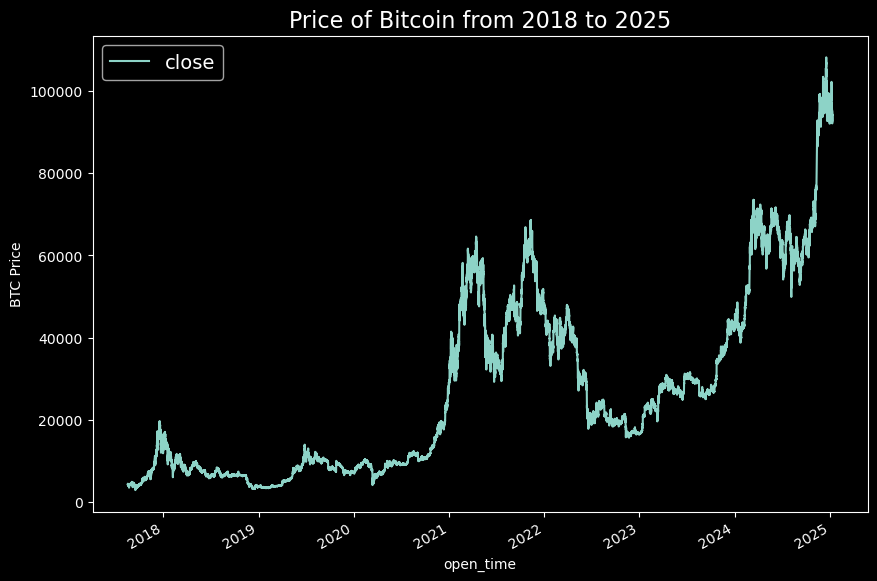

In [8]:
with plt.style.context('dark_background'):
    bitcoin_prices.plot(figsize=(10, 7))
    plt.ylabel("BTC Price")
    plt.title("Price of Bitcoin from 2018 to 2025", fontsize=16)
    plt.legend(fontsize=14);

In [9]:
# Importing and formatting historical Bitcoin data with Python
timesteps = []
btc_price = []
csv_reader = pd.read_csv("data/btc1h_usdt.csv")
timesteps = csv_reader["open_time"].tolist()
btc_price = csv_reader["close"].tolist()
# View first 10 of each
timesteps[:10], btc_price[:10]

(['2017-08-17 04:00:00.000',
  '2017-08-17 05:00:00.000',
  '2017-08-17 06:00:00.000',
  '2017-08-17 07:00:00.000',
  '2017-08-17 08:00:00.000',
  '2017-08-17 09:00:00.000',
  '2017-08-17 10:00:00.000',
  '2017-08-17 11:00:00.000',
  '2017-08-17 12:00:00.000',
  '2017-08-17 13:00:00.000'],
 [4308.83,
  4315.32,
  4324.35,
  4349.99,
  4360.69,
  4444.0,
  4460.0,
  4427.3,
  4411.0,
  4459.0])

In [10]:
# Plot from CSV
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.plot(timesteps, btc_price)
    plt.title("Price of Bitcoin from 2018 to 2025", fontsize=16)
    plt.xlabel("open_time")
    plt.ylabel("close");

In [11]:
# Get bitcoin date array
timesteps = bitcoin_prices.index.to_numpy()
prices = bitcoin_prices["close"].to_numpy()

timesteps[:10], prices[:10]

(array(['2017-08-17T04:00:00.000000000', '2017-08-17T05:00:00.000000000',
        '2017-08-17T06:00:00.000000000', '2017-08-17T07:00:00.000000000',
        '2017-08-17T08:00:00.000000000', '2017-08-17T09:00:00.000000000',
        '2017-08-17T10:00:00.000000000', '2017-08-17T11:00:00.000000000',
        '2017-08-17T12:00:00.000000000', '2017-08-17T13:00:00.000000000'],
       dtype='datetime64[ns]'),
 array([4308.83, 4315.32, 4324.35, 4349.99, 4360.69, 4444.  , 4460.  ,
        4427.3 , 4411.  , 4459.  ]))

In [12]:

# Create train and test splits the right way for time series data
split_size = int(0.8 * len(prices)) # 80% train, 20% test

# Create train data splits (everything before the split)
X_train, y_train = timesteps[:split_size], prices[:split_size]

# Create test data splits (everything after the split)
X_test, y_test = timesteps[split_size:], prices[split_size:]

len(X_train), len(X_test), len(y_train), len(y_test)

(51784, 12946, 51784, 12946)

In [13]:
# Create a function to plot time series data
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across timesteps).
  
  Parameters
  ---------
  timesteps : array of timesteps
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (setting a value will index from end of timesteps & values)
  label : label to show on plot of values
  """
  # Plot the series
  with plt.style.context('dark_background'):
      plt.plot(timesteps[start:end], values[start:end], format, label=label)
      plt.xlabel("Time")
      plt.ylabel("BTC Price")
      if label:
        plt.legend(fontsize=14) # make label bigger
      plt.grid(True)

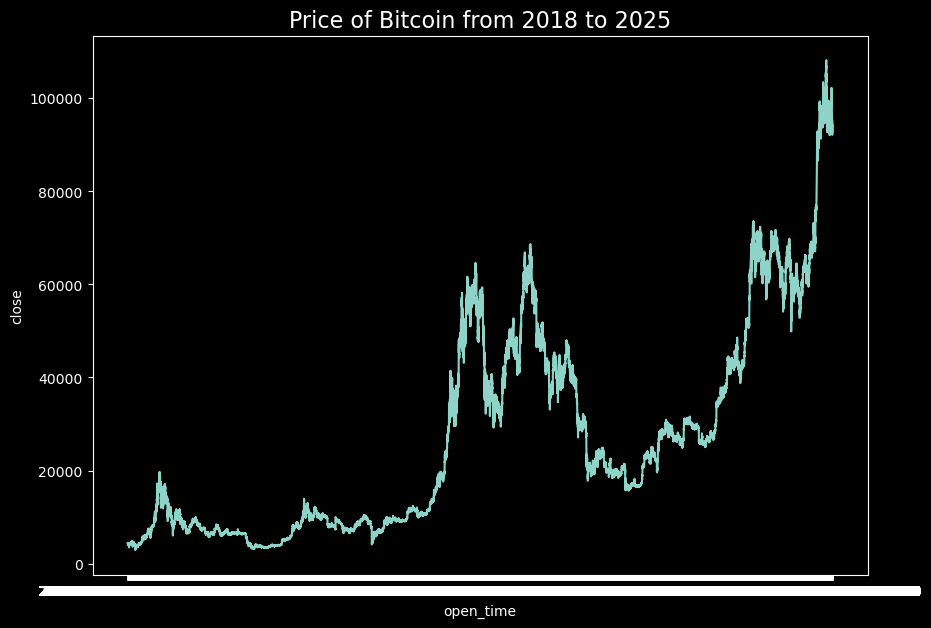

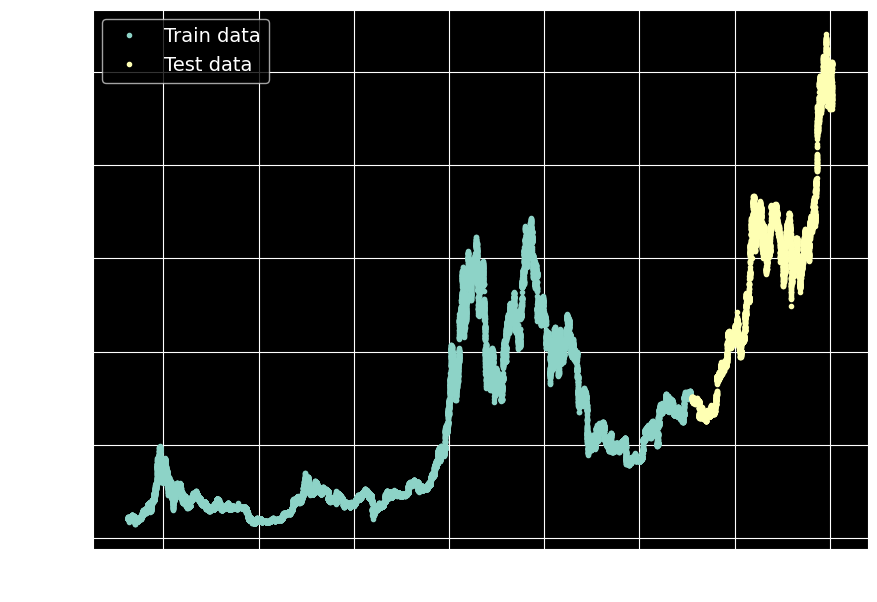

In [14]:
# Try out our plotting function~
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")
plt.show();

In [15]:
#
#    horizon = number of timesteps to predict into future
#    window = number of timesteps from past used to predict horizon

#For example, if we wanted to predict the price of Bitcoin for tomorrow (1 day in the future) using the previous week's worth of Bitcoin prices (7 days in the past), the horizon would be 1 and the window would be 7.

#Now, how about those modelling experiments?
#Model Number 	Model Type 	Horizon size 	Window size 	Extra data
# 0 	Naïve model (baseline) 	NA 	NA 	NA
# 1 	Dense model 	1 	7 	NA
# 2 	Same as 1 	1 	30 	NA
# 3 	Same as 1 	7 	30 	NA
# 4 	Conv1D 	1 	7 	NA
# 5 	LSTM 	1 	7 	NA

In [16]:
#Create naive forecast
# Create a naïve forecast
naive_forecast = y_test[:-1] # Naïve forecast equals every value excluding the last value
naive_forecast[:10], naive_forecast[-10:] # View frist 10 and last 10 

(array([30264.55, 30327.99, 30295.  , 30284.9 , 30221.53, 30229.58,
        29782.19, 29810.18, 29716.69, 29756.73]),
 array([93214.23, 93030.87, 93516.62, 93462.43, 93465.23, 93405.6 ,
        92113.06, 92786.54, 94363.64, 94230.62]))

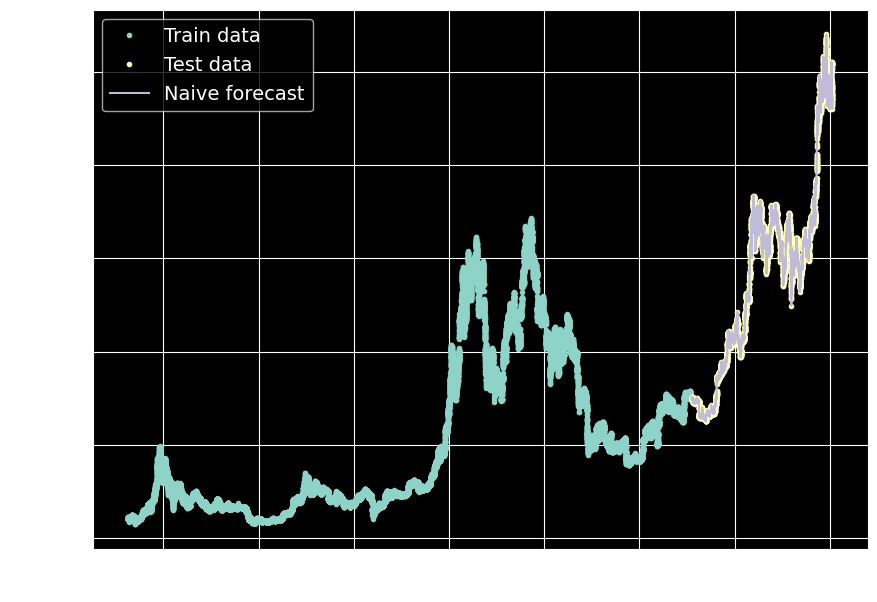

In [17]:
# Plot naive forecast
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", label="Naive forecast");
plt.show();

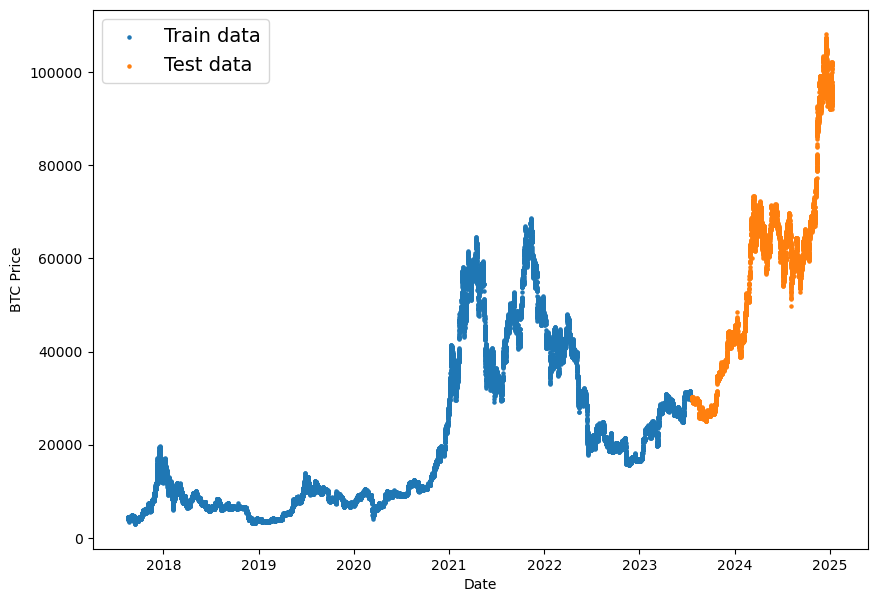

In [18]:
# Plot correctly made splits

plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, s=5, label="Train data")
plt.scatter(X_test, y_test, s=5, label="Test data")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend(fontsize=14)
plt.show();

#  As it is a timeseries data, we shouldn't reshuffle it

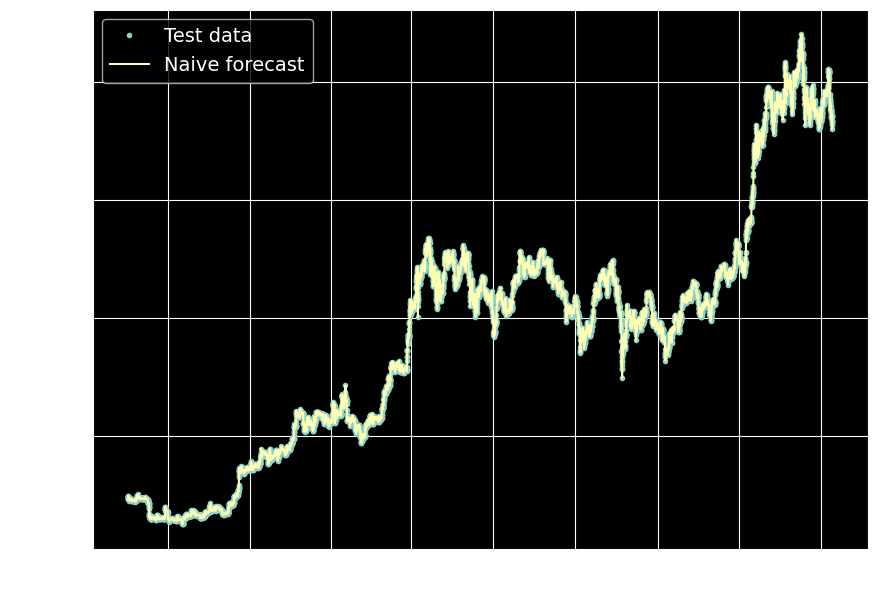

In [19]:
plt.figure(figsize=(10, 7))
offset = 300 # offset the values by 300 timesteps 
plot_time_series(timesteps=X_test, values=y_test, start=offset, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", start=offset, label="Naive forecast");
plt.show();

In [20]:
# -----------Evaluation time series model ------------- #
#You'll notice the version of MASE above doesn't take in the training values like sktime's mae_loss(). In our case, we're comparing the MAE of our predictions on the test to the MAE of the naïve forecast on the test set.

# In practice, if we've created the function correctly, the naïve model should achieve an MASE of 1 (or very close to 1). Any model worse than the naïve forecast will achieve an MASE of >1 and any model better than the naïve forecast will achieve an MASE of <1.

# Let's put each of our different evaluation metrics together into a function.
import tensorflow as tf
# !pip install tf-keras

In [21]:
# MASE implemented courtesy of sktime - https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16
def mean_absolute_scaled_error(y_true, y_pred):
  """
  Implement MASE (assuming no seasonality of data).
  """
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))

  # Find MAE of naive forecast (no seasonality)
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1])) # our seasonality is 1 day (hence the shifting of 1 day)

  return mae / mae_naive_no_season

In [22]:
#!pip install --upgrade tensorflow
import tensorflow as tf

def mean_absolute_scaled_error(y_true, y_pred, seasonality=1):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    naive_mae = tf.reduce_mean(tf.abs(y_true[seasonality:] - y_true[:-seasonality]))
    return mae / naive_mae

def evaluate_preds(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    mae = tf.keras.losses.MAE(y_true, y_pred)
    mse = tf.keras.losses.MSE(y_true, y_pred)
    rmse = tf.sqrt(mse)
    mape = tf.keras.losses.MAPE(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_true, y_pred)
    
    return {
        "mae": mae.numpy(),
        "mse": mse.numpy(),
        "rmse": rmse.numpy(),
        "mape": mape.numpy(),
        "mase": mase.numpy()
    }


In [23]:
def evaluate_preds(y_true, y_pred):
  # Make sure float32 (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate various metrics
  mae = tf.keras.losses.MAE(y_true, y_pred)
  mse = tf.keras.losses.MSE(y_true, y_pred)
  rmse = tf.sqrt(mse)
  mape = tf.keras.losses.MAPE(y_true, y_pred)
  mase = mean_absolute_scaled_error(y_true, y_pred)
  
  return {"mae": mae.numpy(),
          "mse": mse.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape.numpy(),
          "mase": mase.numpy()}

In [24]:
naive_results = evaluate_preds(y_true=y_test[1:],
                               y_pred=naive_forecast)
naive_results


{'mae': 193.85179,
 'mse': 104315.82,
 'rmse': 322.97958,
 'mape': 0.32693344,
 'mase': 0.9999479}

In [25]:
# Find average price of Bitcoin in test dataset
tf.reduce_mean(y_test).numpy()

56162.368610381585

In [26]:
##


# Okay, looking at these two values is starting to give us an idea of how our model is performing:

#    The average price of Bitcoin in the test dataset is: $20,056 (note: average may not be the best measure here, since the highest price is over 3x this value and the lowest price is over 4x lower)

#    Each prediction in naive forecast is on average off by: $567

#Is this enough to say it's a good model?

#That's up your own interpretation. Personally, I'd prefer a model which was closer to the mark.

#How about we try and build one?


In [27]:
HORIZON = 1 # predict 1 step at a time
WINDOW_SIZE = 7 # use a week worth of timesteps to predict the horizon

In [28]:
 # Create function to label windowed data
def get_labelled_windows(x, horizon=1):
  """
  Creates labels for windowed dataset.

  E.g. if horizon=1 (default)
  Input: [1, 2, 3, 4, 5, 6] -> Output: ([1, 2, 3, 4, 5], [6])
  """
  return x[:, :-horizon], x[:, -horizon:]

In [29]:
# Test out the window labelling function
test_window, test_label = get_labelled_windows(tf.expand_dims(tf.range(8)+1, axis=0), horizon=HORIZON)
print(f"Window: {tf.squeeze(test_window).numpy()} -> Label: {tf.squeeze(test_label).numpy()}")

Window: [1 2 3 4 5 6 7] -> Label: 8


In [30]:
##Create function to view NumPy arrays as windows 
def make_windows(x, window_size=7, horizon=1):
  """
  Turns a 1D array into a 2D array of sequential windows of window_size.
  """
  # 1. Create a window of specific window_size (add the horizon on the end for later labelling)
  window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
  # print(f"Window step:\n {window_step}")

  # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T # create 2D array of windows of size window_size
  # print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

  # 3. Index on the target array (time series) with 2D array of multiple window steps
  windowed_array = x[window_indexes]

  # 4. Get the labelled windows
  windows, labels = get_labelled_windows(windowed_array, horizon=horizon)

  return windows, labels

In [31]:
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(64723, 64723)

In [32]:
# View the first 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i]} -> Label: {full_labels[i]}")

Window: [4308.83 4315.32 4324.35 4349.99 4360.69 4444.   4460.  ] -> Label: [4427.3]
Window: [4315.32 4324.35 4349.99 4360.69 4444.   4460.   4427.3 ] -> Label: [4411.]
Window: [4324.35 4349.99 4360.69 4444.   4460.   4427.3  4411.  ] -> Label: [4459.]


In [33]:
# View the last 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i-3]} -> Label: {full_labels[i-3]}")

Window: [93030.87 93516.62 93462.43 93465.23 93405.6  92113.06 92786.54] -> Label: [94363.64]
Window: [93516.62 93462.43 93465.23 93405.6  92113.06 92786.54 94363.64] -> Label: [94230.62]
Window: [93462.43 93465.23 93405.6  92113.06 92786.54 94363.64 94230.62] -> Label: [92795.16]


In [34]:
# Make the train/test splits
def make_train_test_splits(windows, labels, test_split=0.2):
  """
  Splits matching pairs of windows and labels into train and test splits.
  """
  split_size = int(len(windows) * (1-test_split)) # this will default to 80% train/20% test
  train_windows = windows[:split_size]
  train_labels = labels[:split_size]
  test_windows = windows[split_size:]
  test_labels = labels[split_size:]
  return train_windows, test_windows, train_labels, test_labels

In [35]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(51778, 12945, 51778, 12945)

In [36]:
train_windows[:5], train_labels[:5]

(array([[4308.83, 4315.32, 4324.35, 4349.99, 4360.69, 4444.  , 4460.  ],
        [4315.32, 4324.35, 4349.99, 4360.69, 4444.  , 4460.  , 4427.3 ],
        [4324.35, 4349.99, 4360.69, 4444.  , 4460.  , 4427.3 , 4411.  ],
        [4349.99, 4360.69, 4444.  , 4460.  , 4427.3 , 4411.  , 4459.  ],
        [4360.69, 4444.  , 4460.  , 4427.3 , 4411.  , 4459.  , 4470.82]]),
 array([[4427.3 ],
        [4411.  ],
        [4459.  ],
        [4470.82],
        [4352.34]]))

In [37]:
# Check to see if same (accounting for horizon and window size)
np.array_equal(np.squeeze(train_labels[:-HORIZON-1]), y_train[WINDOW_SIZE:])

False

In [38]:
import os

# Create a function to implement a ModelCheckpoint callback with a specific filename 
def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name), # create filepath to save model
                                            verbose=0, # only output a limited amount of text
                                            save_best_only=True) # save only the best model to file

In [39]:
import os
import tensorflow as tf
from tensorflow.keras import layers

# Set random seed for reproducibility
tf.random.set_seed(42)

# Function to create a ModelCheckpoint callback
def create_model_checkpoint(model_name, save_path="model_experiments"):
    """Creates a ModelCheckpoint callback to save the best model."""
    filepath = os.path.join(save_path, model_name + ".keras")  # Ensure `.keras` extension
    return tf.keras.callbacks.ModelCheckpoint(filepath=filepath,
                                              verbose=0,
                                              save_best_only=True)

# Construct model
model_1 = tf.keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(HORIZON, activation="linear")  # Linear activation = no activation
], name="model_1_dense")  # Give the model a name for saving

# Compile model
model_1.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"])  # MAE as both loss and metric

# Fit model
model_1.fit(x=train_windows,  # Train windows (7 timesteps of Bitcoin prices)
            y=train_labels,    # Horizon value of 1 (previous 7 timesteps → predict next day)
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_1.name)])  # Save best model


Epoch 1/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3927.1433 - mae: 3927.1433 - val_loss: 377.6435 - val_mae: 377.6435
Epoch 2/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 174.7604 - mae: 174.7604 - val_loss: 297.8517 - val_mae: 297.8517
Epoch 3/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 164.9260 - mae: 164.9260 - val_loss: 337.6725 - val_mae: 337.6725
Epoch 4/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 153.5217 - mae: 153.5217 - val_loss: 365.3855 - val_mae: 365.3855
Epoch 5/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 153.0278 - mae: 153.0278 - val_loss: 279.0496 - val_mae: 279.0496
Epoch 6/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 156.9685 - mae: 156.9685 - val_loss: 354.9461 - val_mae: 354.9461
Epoch 7/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 140.8814 - mae: 140.8814 - val_loss: 229.9653 - val_mae: 229.9653
Epoch 8/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 143.3207 - mae: 143.3207 - val_loss: 310.8495 - 

In [40]:
model_1.evaluate(test_windows, test_labels)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 128.6990 - mae: 128.6990


[204.3580322265625, 204.3580322265625]

In [41]:
# Load the saved best-performing model and evaluate on test data
model_1 = tf.keras.models.load_model("model_experiments/model_1_dense.keras")  # Ensure .keras extension
model_1.evaluate(test_windows, test_labels)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 119.8198 - mae: 119.8198


[193.4866943359375, 193.4866943359375]

In [42]:

def make_preds(model, input_data):
  """
  Uses model to make predictions on input_data.

  Parameters
  ----------
  model: trained model 
  input_data: windowed input data (same kind of data model was trained on)

  Returns model predictions on input_data.
  """
  forecast = model.predict(input_data)
  return tf.squeeze(forecast) # return 1D array of predictions

In [43]:
# Make predictions using model_1 on the test dataset and view the results
model_1_preds = make_preds(model_1, test_windows)
len(model_1_preds), model_1_preds[:10]

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(12945,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([30253.023, 30316.373, 30299.49 , 30289.06 , 30237.408, 30236.57 ,
        29863.736, 29829.209, 29752.432, 29765.51 ], dtype=float32)>)

In [44]:
# Evaluate preds
model_1_results = evaluate_preds(y_true=tf.squeeze(test_labels), # reduce to right shape
                                 y_pred=model_1_preds)
model_1_results

{'mae': 193.48665,
 'mse': 106994.01,
 'rmse': 327.0994,
 'mape': 0.32606652,
 'mase': 0.9980644}

In [45]:
#compare to aniive forecast predict
naive_results

{'mae': 193.85179,
 'mse': 104315.82,
 'rmse': 322.97958,
 'mape': 0.32693344,
 'mase': 0.9999479}

In [46]:
# It looks like our naïve model beats our first deep model on nearly every metric.

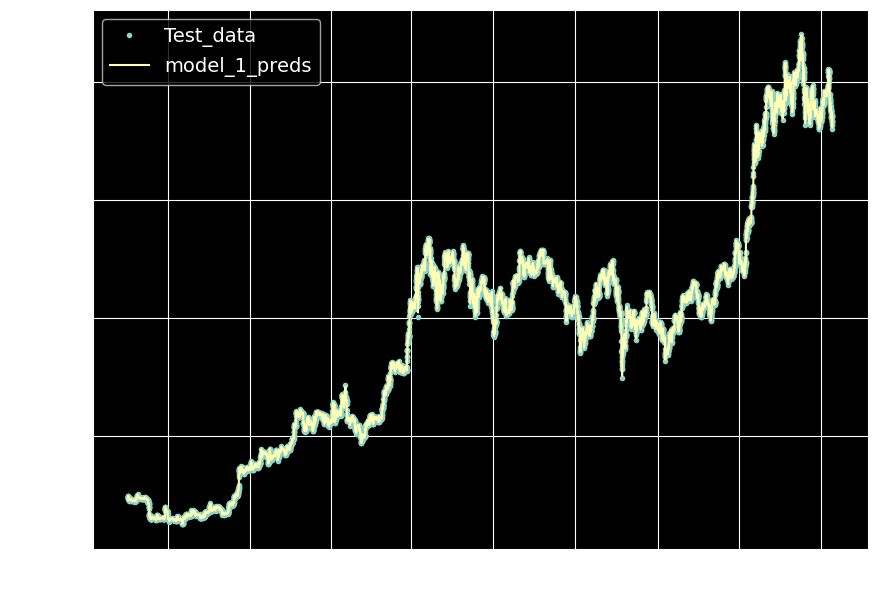

In [47]:

offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset and index into test_labels to ensure correct plotting
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_1_preds, start=offset, format="-", label="model_1_preds")
plt.show();

In [48]:
#####--------------------------MODEL 2 -------------------------#####
HORIZON = 1 # predict one step at a time
WINDOW_SIZE = 30 # use 30 timesteps in the past

In [49]:
# Make windowed data with appropriate horizon and window sizes
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(64700, 64700)

In [50]:
# Make train and testing windows
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows, labels=full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(51760, 12940, 51760, 12940)

In [51]:
tf.random.set_seed(42)

# Create model (same model as model 1 but data input will be different)
model_2 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON) # need to predict horizon number of steps into the future
], name="model_2_dense")

model_2.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

model_2.fit(train_windows,
            train_labels,
            epochs=100,
            batch_size=128,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_2.name)])

In [52]:
# Evaluate model 2 preds
model_2.evaluate(test_windows, test_labels)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 302.1172


427.3892517089844

In [53]:
# Load in best performing model
model_2 = tf.keras.models.load_model("model_experiments/model_2_dense.keras")  # Ensure .keras extension
model_2.evaluate(test_windows, test_labels)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 130.7995


211.29258728027344

In [54]:
# Get forecast predictions
model_2_preds = make_preds(model_2,
                           input_data=test_windows)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [55]:
# Evaluate results for model 2 predictions
model_2_results = evaluate_preds(y_true=tf.squeeze(test_labels), # remove 1 dimension of test labels
                                 y_pred=model_2_preds)
model_2_results

{'mae': 211.29266,
 'mse': 126634.586,
 'rmse': 355.85754,
 'mape': 0.3558929,
 'mase': 1.0897363}

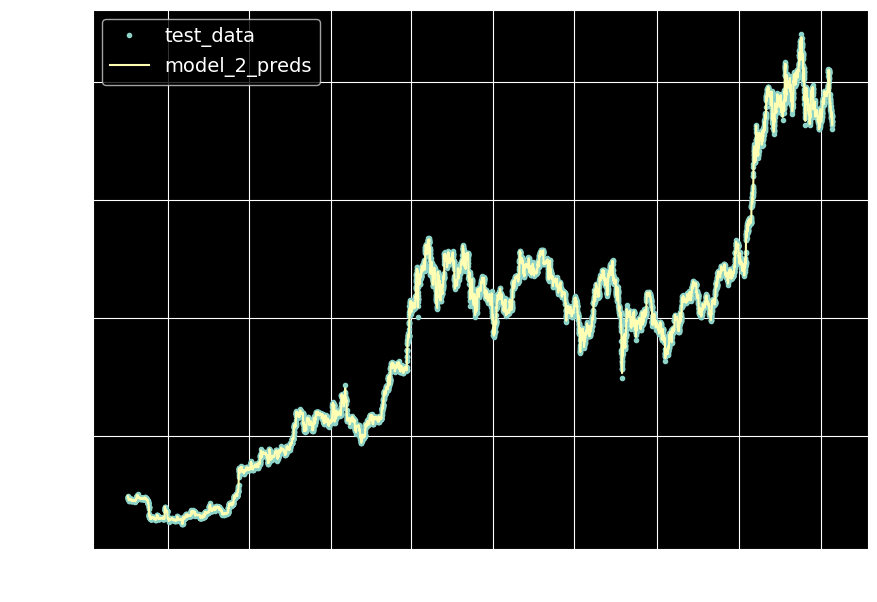

In [56]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_2_preds, start=offset, format="-", label="model_2_preds") 
plt.show();

In [57]:
#######------------------ MODEL 3 - ---------------------------###
# 
HORIZON = 7
WINDOW_SIZE = 30

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(64694, 64694)

In [58]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows, labels=full_labels, test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(51755, 12939, 51755, 12939)

In [59]:
tf.random.set_seed(42)

# Create model (same as model_1 except with different data input size)
model_3 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON)
], name="model_3_dense")

model_3.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

model_3.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_3.name)])

In [60]:
# How did our model with a larger window size and horizon go?
model_3.evaluate(test_windows, test_labels)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 298.1044


450.65155029296875

In [61]:
# Load in best version of model_3 and evaluate
model_3 = tf.keras.models.load_model("model_experiments/model_3_dense.keras")
model_3.evaluate(test_windows, test_labels)


405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 247.8533


396.3157043457031

In [62]:
# The predictions are going to be 7 steps at a time (this is the HORIZON size)
model_3_preds = make_preds(model_3,
                           input_data=test_windows)
model_3_preds[:5]

405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step


<tf.Tensor: shape=(5, 7), dtype=float32, numpy=
array([[30268.297, 30227.188, 30187.086, 30189.834, 30253.168, 30238.79 ,
        30151.387],
       [30328.105, 30290.354, 30221.002, 30257.557, 30309.967, 30297.805,
        30206.76 ],
       [30364.635, 30313.611, 30257.594, 30264.508, 30328.555, 30340.77 ,
        30229.662],
       [30328.662, 30268.2  , 30210.828, 30218.389, 30278.299, 30290.535,
        30193.96 ],
       [30306.295, 30269.117, 30203.732, 30199.545, 30262.688, 30292.926,
        30178.611]], dtype=float32)>

In [63]:
# Calculate model_3 results - these are going to be multi-dimensional because
# we're trying to predict more than one step at a time.
model_3_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_3_preds)
model_3_results

{'mae': array([154.0586 , 224.64787, 328.2193 , ..., 588.269  , 583.11273,
        537.13055], dtype=float32),
 'mse': array([ 49170.848, 108343.516, 161443.62 , ..., 577224.9  , 493987.72 ,
        431431.   ], dtype=float32),
 'rmse': array([221.74501, 329.15576, 401.80048, ..., 759.7532 , 702.8426 ,
        656.83405], dtype=float32),
 'mape': array([0.5148974 , 0.7540868 , 1.1012102 , ..., 0.63100284, 0.6242026 ,
        0.5756865 ], dtype=float32),
 'mase': 2.0458996}

In [64]:
import keras
import tensorflow as tf

def evaluate_preds(y_true, y_pred):
    """Evaluates model predictions using MAE, MSE, and RMSE."""
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    # Use keras.losses instead of tf.keras.losses
    mae = keras.losses.mean_absolute_error(y_true, y_pred)
    mse = keras.losses.mean_squared_error(y_true, y_pred)
    rmse = tf.sqrt(mse)

    return {"mae": mae.numpy().mean(), "mse": mse.numpy().mean(), "rmse": rmse.numpy().mean()}


In [65]:
# Get model_3 results aggregated to single values
odel_3_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_3_preds)
print(model_3_results)

{'mae': array([154.0586 , 224.64787, 328.2193 , ..., 588.269  , 583.11273,
       537.13055], dtype=float32), 'mse': array([ 49170.848, 108343.516, 161443.62 , ..., 577224.9  , 493987.72 ,
       431431.   ], dtype=float32), 'rmse': array([221.74501, 329.15576, 401.80048, ..., 759.7532 , 702.8426 ,
       656.83405], dtype=float32), 'mape': array([0.5148974 , 0.7540868 , 1.1012102 , ..., 0.63100284, 0.6242026 ,
       0.5756865 ], dtype=float32), 'mase': 2.0458996}


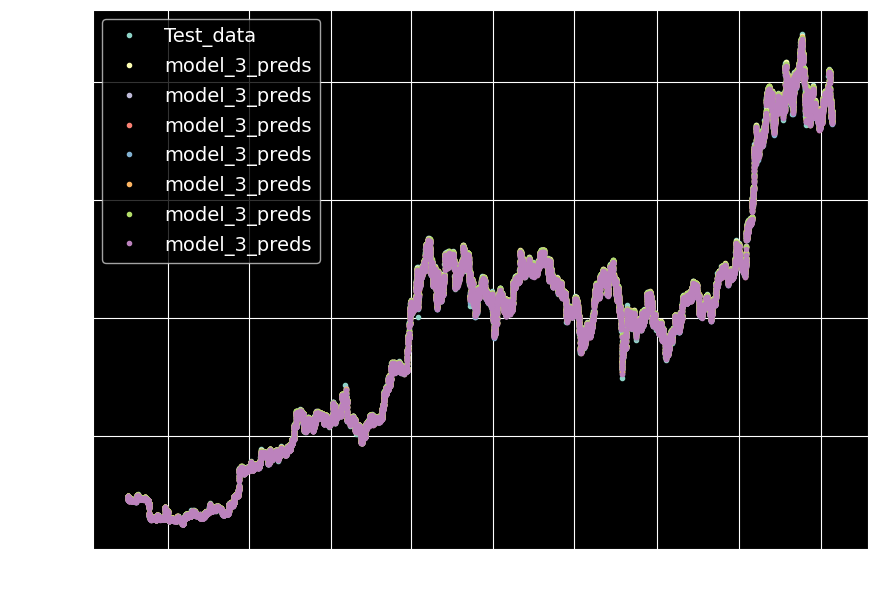

In [66]:
offset = 300
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
# Checking the shape of model_3_preds results in [n_test_samples, HORIZON] (this will screw up the plot)
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_3_preds, start=offset, label="model_3_preds")
plt.show();

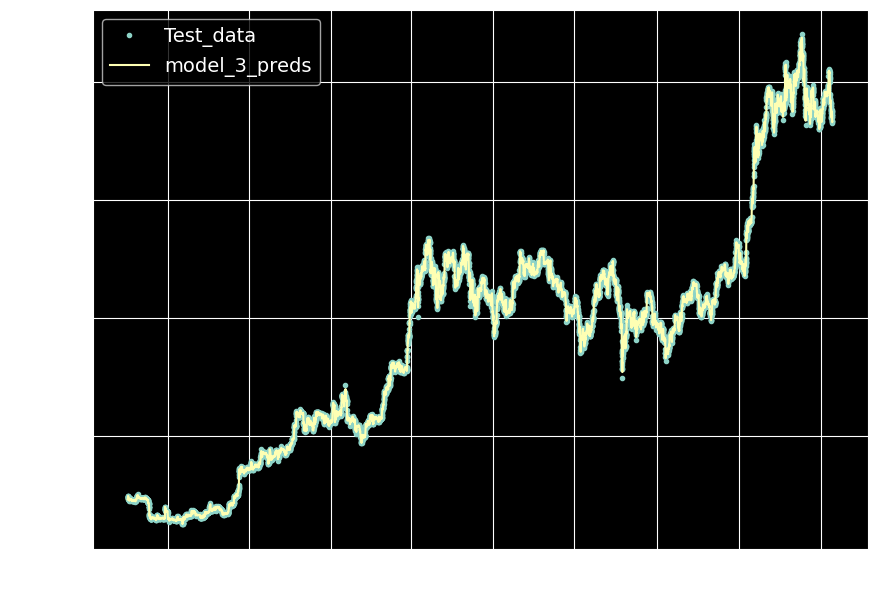

In [67]:
offset = 300
plt.figure(figsize=(10, 7))
# Plot model_3_preds by aggregating them (note: this condenses information so the preds will look fruther ahead than the test data)
plot_time_series(timesteps=X_test[-len(test_windows):], 
                 values=test_labels[:, 0], 
                 start=offset, 
                 label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], 
                 values=tf.reduce_mean(model_3_preds, axis=1), 
                 format="-",
                 start=offset, 
                 label="model_3_preds")

plt.show();

In [68]:
#-------------------------- Comparing performance ----------------------------#


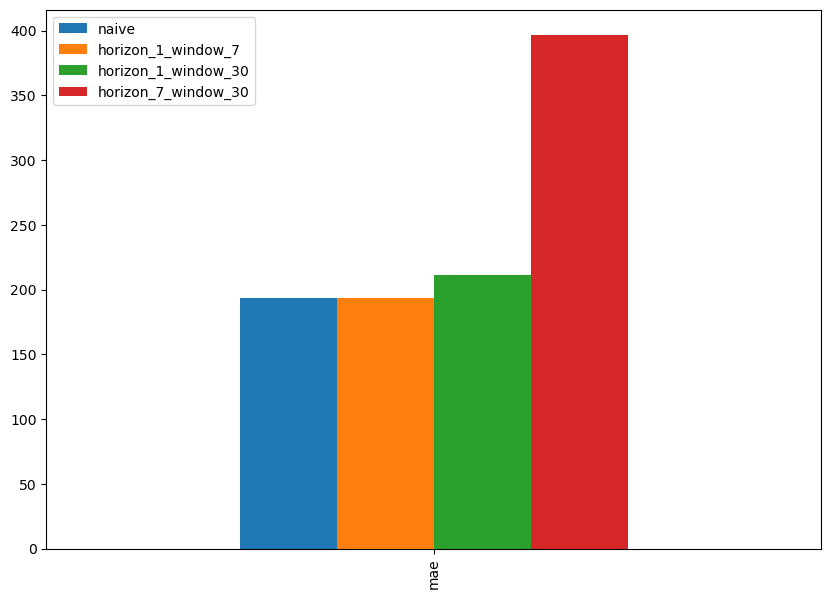

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate mean MAE for each model
data = {
    "naive": [naive_results["mae"].mean()], 
    "horizon_1_window_7": [model_1_results["mae"].mean()], 
    "horizon_1_window_30": [model_2_results["mae"].mean()], 
    "horizon_7_window_30": [model_3_results["mae"].mean()]
}

df = pd.DataFrame(data, index=["mae"])

df.plot(figsize=(10, 7), kind="bar")
plt.show()


In [ ]:
###################-.-------------------------------------------------------------------
#Model 4: Conv1D¶

#Onto the next modelling experiment!

#This time, we'll be using a Conv1D model. Because as we saw in the sequence modelling notebook, Conv1D models can be used for seq2seq (sequence to sequence) problems.

#In our case, the input sequence is the previous 7 days of Bitcoin price data and the output is the next day (in seq2seq terms this is called a many to one problem). Before we build a Conv1D model, let's recreate our datasets.


In [74]:
HORIZON = 1 # predict next day
WINDOW_SIZE = 7 # use previous week worth of data

In [76]:
# Create windowed dataset
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(64723, 64723)

In [78]:
# Create train/test splits
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(51778, 12945, 51778, 12945)

In [80]:
# Check data sample shapes
train_windows[0].shape # returns (WINDOW_SIZE, )

(7,)

In [132]:
# Before we pass our data to the Conv1D layer, we have to reshape it in order to make sure it works
x = tf.constant(train_windows[0])
expand_dims_layer = layers.Lambda(lambda x: tf.expand_dims(x, axis=1)) # add an extra dimension for timesteps
print(f"Original shape: {x.shape}") # (WINDOW_SIZE)
print(f"Expanded shape: {expand_dims_layer(x).shape}") # (WINDOW_SIZE, input_dim) 
print(f"Original values with expanded shape:\n {expand_dims_layer(x)}")

Original shape: (7,)
Expanded shape: (7, 1)
Original values with expanded shape:
 [[4308.83]
 [4315.32]
 [4324.35]
 [4349.99]
 [4360.69]
 [4444.  ]
 [4460.  ]]


In [134]:
tf.random.set_seed(42)

# Create model
model_4 = tf.keras.Sequential([
  # Create Lambda layer to reshape inputs, without this layer, the model will error
  layers.Lambda(lambda x: tf.expand_dims(x, axis=1)), # resize the inputs to adjust for window size / Conv1D 3D input requirements
  layers.Conv1D(filters=128, kernel_size=5, padding="causal", activation="relu"),
  layers.Dense(HORIZON)
], name="model_4_conv1D")

# Compile model
model_4.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Fit model
model_4.fit(train_windows,
            train_labels,
            batch_size=128, 
            epochs=100,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_4.name)])

In [135]:
model_4.summary()

Model: "model_4_conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_4 (Lambda)                    │ (None, 1, 7)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1, 128)              │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1, 1)                │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,213 (55.52 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,476 (37.02 KB)

In [144]:
# Load in best performing Conv1D model and evaluate it on the test data
import tensorflow as tf  # Ensure TensorFlow is imported
model_4 = tf.keras.models.load_model('model_experiments/model_4_conv1D.keras', safe_mode=False)
model_4.evaluate(test_windows, test_labels)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "D:\programs\anaconda\Lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\vasil\AppData\Local\Temp\ipykernel_8700\2037713258.py", line 4, in <module>
    model_4.evaluate(test_windows, test_labels)
  File "C:\Users\vasil\AppData\Roaming\Python\Python311\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "C:/Users/vasil/AppData/Local/Temp/ipykernel_8700/4102691582.py", line 6, in <lambda>
NameError: Exception encountered when calling Lambda.call().

name 'tf' is not defined

Arguments received by Lambda.call():
  • inputs=tf.Tensor(shape=(None, 7), dtype=float32)
  • mask=None
  • training=False

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "D:\programs\anaconda\Lib\site-packages\IPython\core\interactives

In [140]:
# Make predictions
model_4_preds = make_preds(model_4, test_windows)
model_4_preds[:10]

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "D:\programs\anaconda\Lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\vasil\AppData\Local\Temp\ipykernel_8700\2172289883.py", line 2, in <module>
    model_4_preds = make_preds(model_4, test_windows)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vasil\AppData\Local\Temp\ipykernel_8700\3042064211.py", line 12, in make_preds
    forecast = model.predict(input_data)
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vasil\AppData\Roaming\Python\Python311\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "C:/Users/vasil/AppData/Local/Temp/ipykernel_8700/4102691582.py", line 6, in <lambda>
NameError: Exception encountered when calling Lambda.call().

name 'tf' is not defined

Arguments received by Lambda.call():
  • inputs=tf.Tensor(shap

In [142]:
# Evaluate predictions
model_4_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_4_preds)
model_4_results

NameError: name 'model_4_preds' is not defined